In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
%pip install google-cloud-bigquery pandas-gbq

Note: you may need to restart the kernel to use updated packages.


In [5]:
from google.cloud import bigquery
import pandas as pd

# Set up BigQuery Client
client = bigquery.Client(project="scalable-streaming-analytics")

# Define the SQL Query
query = """
SELECT * 
FROM `scalable-streaming-analytics.streaming_data.events`
LIMIT 10
"""

# Execute the Query
df = client.query(query).to_dataframe()

# Display Data
df.head()



c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:1820: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,event,content_id,timestamp
0,1,watch,content_5,1.739140e+09


In [6]:
import pandas as pd

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Check for missing values
print(df.isnull().sum())

# Display summary statistics
print(df.describe())

# Display first few rows
df.head()


user_id       0
event         0
content_id    0
timestamp     0
dtype: int64
       user_id            timestamp
count      1.0                    1
mean       1.0  2025-02-09 22:28:09
min        1.0  2025-02-09 22:28:09
25%        1.0  2025-02-09 22:28:09
50%        1.0  2025-02-09 22:28:09
75%        1.0  2025-02-09 22:28:09
max        1.0  2025-02-09 22:28:09
std       <NA>                  NaN


,user_id,event,content_id,timestamp
0,1,watch,content_5,2025-02-09 22:28:09


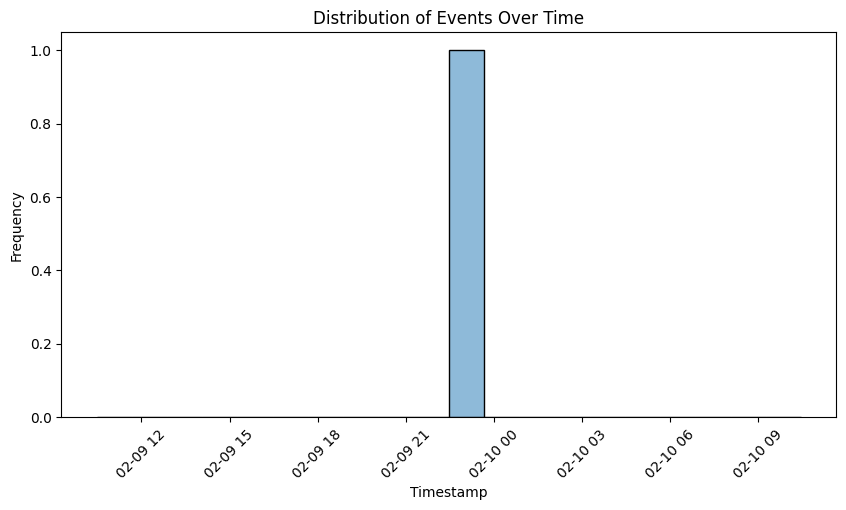

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot events over time
plt.figure(figsize=(10, 5))
sns.histplot(df['timestamp'], bins=20, kde=True)
plt.xlabel('Timestamp')
plt.ylabel('Frequency')
plt.title('Distribution of Events Over Time')
plt.xticks(rotation=45)
plt.show()


In [8]:
# Check the latest entries
query = """
SELECT * FROM `scalable-streaming-analytics.streaming_data.events`
ORDER BY timestamp DESC
LIMIT 10
"""
df = client.query(query).to_dataframe()
df.head()


c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:1820: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,event,content_id,timestamp
0,1,watch,content_5,1.739140e+09


In [1]:
from google.cloud import bigquery

# Initialize BigQuery Client
client = bigquery.Client()

# Query to fetch latest events
query = """
SELECT * 
FROM `scalable-streaming-analytics.streaming_data.events`
ORDER BY timestamp DESC
LIMIT 100;
"""

# Load into Pandas DataFrame
df = client.query(query).to_dataframe()
df.head()


c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:1820: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,event,content_id,timestamp
0,19,like,content_9,1.739506e+09
1,34,subscribe,content_39,1.739506e+09
2,45,subscribe,content_44,1.739506e+09
3,72,subscribe,content_42,1.739506e+09
4,57,subscribe,content_36,1.739506e+09


In [2]:
# Check Data Types and Missing Values
df.info()

# Check Unique Values in the "event" Column
df["event"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   user_id     100 non-null    Int64  
 1   event       100 non-null    object 
 2   content_id  100 non-null    object 
 3   timestamp   100 non-null    float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 3.4+ KB


event
like         30
subscribe    28
share        25
watch        17
Name: count, dtype: int64

In [3]:
import pandas as pd

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Display the updated dataframe
df.head()


,user_id,event,content_id,timestamp
0,19,like,content_9,2025-02-14 04:05:48.733960867
1,34,subscribe,content_39,2025-02-14 04:05:46.657061815
2,45,subscribe,content_44,2025-02-14 04:05:44.593274832
3,72,subscribe,content_42,2025-02-14 04:05:42.533634901
4,57,subscribe,content_36,2025-02-14 04:05:40.475090027


C:\Users\bthea\AppData\Local\Temp\ipykernel_18580\136674852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["event"], order=df["event"].value_counts().index, palette="viridis")


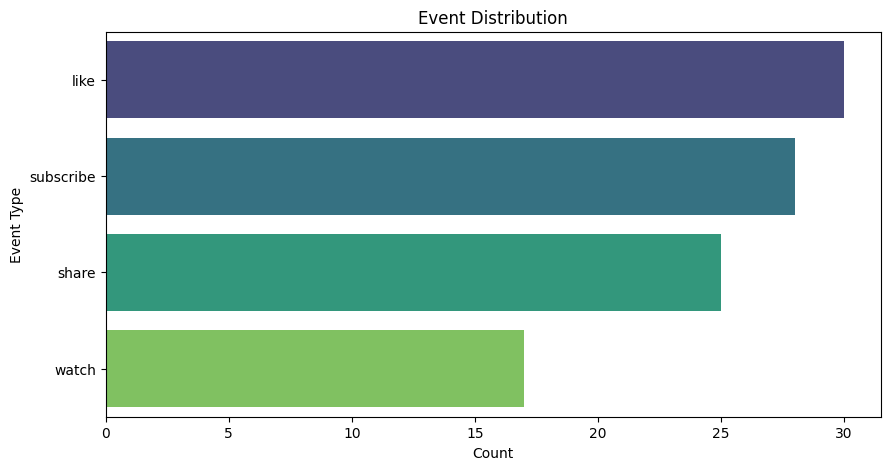

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(y=df["event"], order=df["event"].value_counts().index, palette="viridis")
plt.title("Event Distribution")
plt.xlabel("Count")
plt.ylabel("Event Type")
plt.show()


C:\Users\bthea\AppData\Local\Temp\ipykernel_18580\1046141259.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.set_index("timestamp")["event"].resample("H").count().plot()
c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


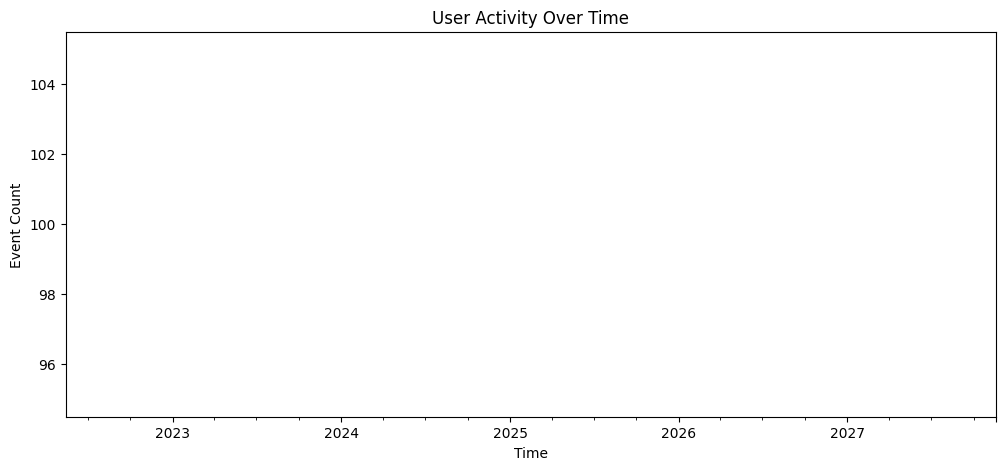

In [5]:
plt.figure(figsize=(12, 5))
df.set_index("timestamp")["event"].resample("H").count().plot()
plt.title("User Activity Over Time")
plt.xlabel("Time")
plt.ylabel("Event Count")
plt.show()
